<a href="https://colab.research.google.com/github/Kkurzo/-labs/blob/main/%D0%9B%D0%B0%D0%B1_2_%D0%97%D0%B0%D0%B2%D0%B4__%D0%9C%D0%B5%D0%BB%D1%8C%D0%BD%D0%B8%D1%87%D1%83%D0%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [149]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [150]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [151]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Про набір даних**
Набір даних зазвичай містить такі стовпці:

**PassengerId:** Унікальний ідентифікатор для кожного пасажира.

**Survived**: У цьому стовпці вказується, чи вижив пасажир (1), чи ні (0).

**Pclass** (Клас квитка): Показник соціально-економічного статусу, де 1 – найвищий клас, а 3 – найнижчий.

**Name**: Ім'я пасажира.

**Sex:** Стать пасажира.

**Age:** Вік пасажира. (Примітка: У цьому стовпці можуть бути відсутні значення.)

**SibSp:** Кількість братів і сестер або подружжя пасажира на борту «Титаніка».

**Parch:** Кількість батьків або дітей пасажира на борту «Титаніка».

**Ticket**: Номер квитка.

**Fare**: Сума грошей, яку пасажир сплатив за квиток.

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [153]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [154]:
df["Age"] = df["Age"].fillna(df["Age"].median(skipna=True))

df.drop(["Cabin"], axis=1, inplace=True)
df.drop(["Embarked"], axis=1, inplace=True)

In [155]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [156]:
df = df[["Survived", "Pclass", "Sex", "Age", "Fare"]]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [157]:
df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [158]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
print(f"Data types of the dataset:\n{df.dtypes}")

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


In [159]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


In [160]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


In [161]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


In [162]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


In [163]:
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100
print(f"Share of survived meles: {survival_by_sex[0]:.2f}%")
print(f"Share of survived females: {survival_by_sex[0]:.2f}%")
print(f"Correlation between sex and survival: {df["Sex"].corr(df["Survived"])}")


Share of survived meles: 18.89%
Share of survived females: 18.89%
Correlation between sex and survival: 0.5433513806577555


In [165]:
class1_surv_rate = df[(df["Pclass"] == 1) & (df["Survived"] == 1)].shape[0] / df[df["Pclass"] == 1].shape[0]
class2_surv_rate = df[(df["Pclass"] == 2) & (df["Survived"] == 1)].shape[0] / df[df["Pclass"] == 2].shape[0]
class3_surv_rate = df[(df["Pclass"] == 3) & (df["Survived"] == 1)].shape[0] / df[df["Pclass"] == 3].shape[0]

print(f"Share of survived class 1 passengers {class1_surv_rate * 100:.2f}%")
print(f"Share of survived class 2 passengers {class2_surv_rate * 100:.2f}%")
print(f"Share of survived class 3 passengers {class3_surv_rate * 100:.2f}%")


Share of survived class 1 passengers 62.96%
Share of survived class 2 passengers 47.28%
Share of survived class 3 passengers 24.24%


In [166]:
survived_mean_age = df[df["Survived"] == 1]["Age"].mean()
not_survived_mean_age = df[df["Survived"] == 0]["Age"].mean()
print(f"Mean age of survived passengers: {survived_mean_age:.2f}")
print(f"Mean age of not survived passengers: {not_survived_mean_age:.2f}")

Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


In [171]:
df["Fare_Category"] = pd.qcut(df["Fare"], 6, labels=False)

for i in range(6):
    surv_rate = (
        df[(df["Fare_Category"] == i) & (df["Survived"] == 1)].shape[0]
        / df[df["Fare_Category"] == i].shape[0]
    )

    print(f"Share of survived passengers in bucket {i}: {surv_rate * 100:.2f}%")

Share of survived passengers in bucket 0: 20.51%
Share of survived passengers in bucket 1: 19.08%
Share of survived passengers in bucket 2: 36.69%
Share of survived passengers in bucket 3: 43.62%
Share of survived passengers in bucket 4: 41.78%
Share of survived passengers in bucket 5: 69.80%


In [174]:
for i in range(1, 4):
  for j in range(2):
    surv_rate = df[(df["Pclass"] == i) & (df["Sex"] == j) & (df["Survived"] == 1)].shape[0] / df[(df["Pclass"] == i) & (df["Sex"] == j)].shape[0]
    print(f"Share of survived {"male" if j == 0 else "female"} passenger in class {i}: {surv_rate * 100:.2f}")

Share of survived male passenger in class 1: 36.89
Share of survived female passenger in class 1: 96.81
Share of survived male passenger in class 2: 15.74
Share of survived female passenger in class 2: 92.11
Share of survived male passenger in class 3: 13.54
Share of survived female passenger in class 3: 50.00


<Axes: >

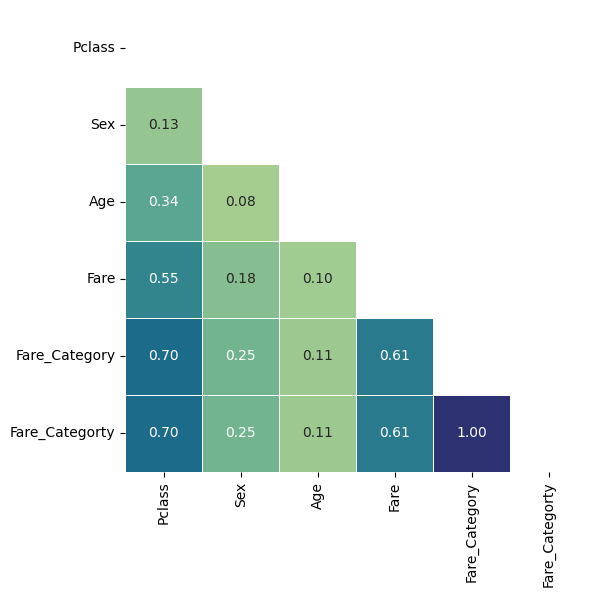

In [175]:
mtx = df.drop("Survived", axis=1).corr(numeric_only=True).abs()
fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap="crest",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
)